# COBYLA Optimizer

# Project 9b: VQE with COBYLA (Gradient-Free)

**Objective:** Run the same VQE problem using COBYLA, a gradient-free optimizer, to compare performance and resilience.

**Theory:**
While gradient-based optimizers (like SLSQP) are fast in perfect math simulations, they struggle on *real* quantum hardware. Because real quantum chips are noisy, the energy readings fluctuate. If the readings fluctuate, the classical computer calculates the "gradient" incorrectly and steps in the wrong direction.

**COBYLA** (Constrained Optimization BY Linear Approximations) does not calculate gradients. It just samples different points and triangulates where the minimum might be. This makes it heavily preferred for Noisy Intermediate-Scale Quantum computing because it is far more resistant to hardware errors.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import EfficientSU2
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define identical parameters to the previous notebook
hamiltonian = SparsePauliOp.from_list([("ZZ", 1.0), ("ZI", -0.5), ("IX", 0.2)])
ansatz = EfficientSU2(num_qubits=2, reps=1, entanglement='linear')
estimator = StatevectorEstimator()
initial_parameters = np.random.rand(ansatz.num_parameters) * 2 * np.pi

print("Environment Ready.")

Environment Ready.


/tmp/ipykernel_20433/3575570191.py:11: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=2, reps=1, entanglement='linear')


## Step 1: Execution and Comparison

We will run the exact same `cost_function` logic, but we will pass `method='COBYLA'` to the SciPy optimizer. Notice how the shape of the convergence graph differs from the gradient descent.

Starting VQE Optimization with COBYLA (Gradient-Free)...

Ground State Energy Found: -1.5197617070593483


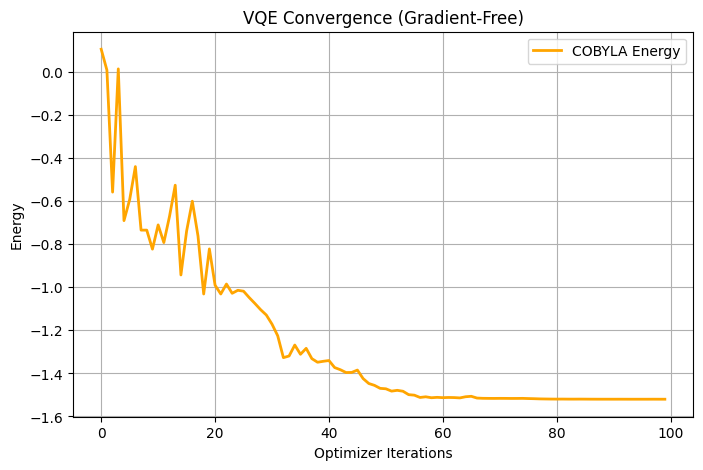

In [2]:
energy_history_cobyla = []

def cost_function_cobyla(params):
    pub = (ansatz, hamiltonian, params)
    result = estimator.run([pub]).result()[0]
    energy = result.data.evs
    energy_history_cobyla.append(energy)
    return energy

print("Starting VQE Optimization with COBYLA (Gradient-Free)...")
result_cobyla = minimize(cost_function_cobyla, initial_parameters, method='COBYLA', options={'maxiter': 100})

print(f"\nGround State Energy Found: {result_cobyla.fun}")

plt.figure(figsize=(8, 5))
plt.plot(energy_history_cobyla, color='orange', linewidth=2, label="COBYLA Energy")
plt.title("VQE Convergence (Gradient-Free)")
plt.xlabel("Optimizer Iterations")
plt.ylabel("Energy")
plt.legend()
plt.grid(True)
plt.show()

## Final Analysis
**What did we observe?**
Unlike the perfectly smooth, steep curve of the gradient descent, the COBYLA graph looks more jagged and usually requires more iterations to plateau. Because it isn't calculating the exact mathematical slope, it is "feeling around in the dark." 

However, on a real IBM quantum computer, this jagged approach will often succeed and find the minimum energy state where gradient descent would fail entirely due to hardware noise.